## Exercise 1

Apparent diffusion coefficient (ADC) can be estimated from an exponential curve.

$$
S(b) = S_0e^{-b \cdot ADC}
$$
$$
ln(S(b)) = ln(S_0)-b \cdot ADC
$$

Where:

S(b) = measured MRI signal at diffusion weighting b

S0 = signal when b = 0

### 1a) Artificial data generation

In [2]:
import numpy as np
import time

nx, ny = 64, 64
ADC_true = np.zeros((nx, ny))
ADC_true[10:30, 10:30] = 0.0007
ADC_true[35:55, 10:30] = 0.0010
ADC_true[20:45, 35:55] = 0.0015
S0 = 1000
bvals = np.array([0, 500, 1000, 1500])

def rician(signal, sigma=20):
    n1 = np.random.normal(0, sigma, signal.shape)
    n2 = np.random.normal(0, sigma, signal.shape)
    return np.sqrt((signal+n1)**2 + n2**2)

data = np.stack([rician(S0*np.exp(-b*ADC_true)) for b in bvals], axis=-1)

### 1b) Estimate ADC from various methods

#### Log Least Squares (log-LS)

In [3]:
ADC_LS = np.zeros_like(ADC_true)
S0_LS = np.zeros_like(ADC_true)

mask = ADC_true > 0
x = bvals

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue
        y = np.log(s)
        A = np.column_stack([np.ones_like(x), x])
        coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        a, b = coeffs  # a = slope and b = intersect
        if b >= 0:
            continue

        ADC_LS[ix, iy] = -1.0 * b
        S0_LS[ix, iy] = np.exp(a)

t_LS = time.time() - t0
print(f"Linear LS time: {t_LS:.3f} s")


Linear LS time: 0.061 s


#### Levenberg-Marquardt (LM)


In [4]:
from scipy.optimize import curve_fit # Bruger LM metode som default

def adc_model(b, S0, ADC):
    return S0 * np.exp(-b * ADC)

ADC_LM = np.zeros_like(ADC_true)
S0_LM = np.zeros_like(ADC_true)

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue

        S0_init = S0_LS[ix, iy] if S0_LS[ix, iy] > 0 else 1000
        ADC_init = ADC_LS[ix, iy] if ADC_LS[ix, iy] > 0 else 0.080

        try:
            popt, _ = curve_fit(
                adc_model, bvals, s,
                p0=[1000, 0.001],
                #p0=[S0_init, ADC_init],
                maxfev=2000
            )
            S0_LM[ix, iy], ADC_LM[ix, iy] = popt
        except RuntimeError:
            ADC_LM[ix, iy] = 0

t_LM = time.time() - t0
print(f"LM time: {t_LM:.3f} s")


LM time: 0.301 s


#### BFGS

In [5]:
from scipy.optimize import minimize
import time

def adc_objective(params, b, signal):
    S0, adc = params
    if S0 <= 0 or adc <= 0:
        return 1e12  # penalize invalid values
    pred = S0 * np.exp(-b * adc)
    return np.sum((signal - pred)**2)


ADC_BFGS = np.zeros_like(ADC_true)
S0_BFGS = np.zeros_like(ADC_true)

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue

        # Initial guess from LS
        S0_init = S0_LS[ix, iy] if S0_LS[ix, iy] > 0 else 1000
        BFGS_init = ADC_LS[ix, iy] if ADC_LS[ix, iy] > 0 else 0.001

        res = minimize(
            adc_objective,
            #x0=[S0_init, BFGS_init],
            x0=[1000, 0.001],
            args=(bvals, s),
            method="BFGS",
            options={"maxiter": 300, "disp": False}
        )

        S0_hat, adc_hat = res.x
        if adc_hat > 0:
            ADC_BFGS[ix, iy] = adc_hat
            S0_BFGS[ix, iy] = S0_hat

t_BFGS = time.time() - t0
print(f"BFGS time: {t_BFGS:.3f} s")


BFGS time: 8.300 s


### Compare maps and noise sensitivity.

RMSE LS: 0.000084
RMSE LM: 0.0000481720
RMSE BFGS: 0.0000481724


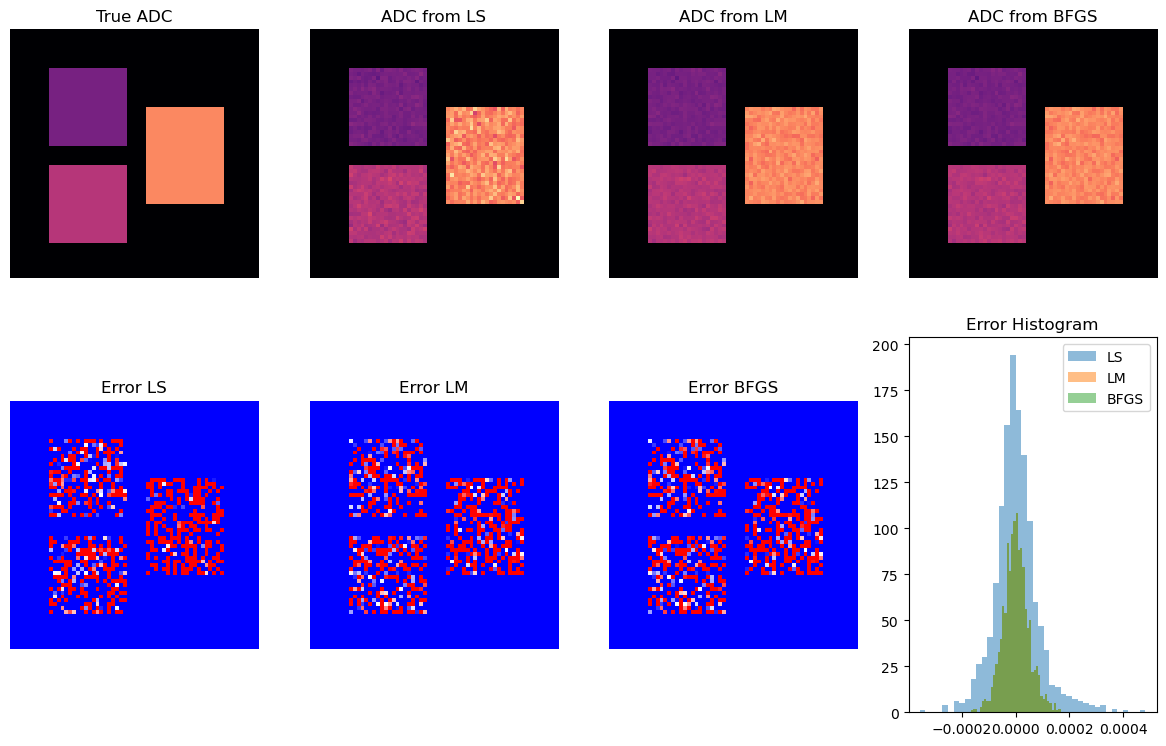

In [6]:
import matplotlib.pyplot as plt

err_LS = (ADC_LS - ADC_true)
err_LM = (ADC_LM - ADC_true)
err_BFGS = (ADC_BFGS - ADC_true)

rmse_LS = np.sqrt(np.mean(err_LS[mask]**2))
rmse_LM = np.sqrt(np.mean(err_LM[mask]**2))
rmse_BFGS = np.sqrt(np.mean(err_BFGS[mask]**2))

print(f"RMSE LS: {rmse_LS:.6f}")
print(f"RMSE LM: {rmse_LM:.10f}")
print(f"RMSE BFGS: {rmse_BFGS:.10f}")

vmin, vmax = 0, 0.002  # ms

plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(ADC_true, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("True ADC")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(ADC_LS, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from LS")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(ADC_LM, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from LM")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(ADC_BFGS, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from BFGS")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(err_LS, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error LS")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(err_LM, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error LM")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(err_BFGS, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error BFGS")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.hist(err_LS[mask].ravel(), bins=40, alpha=0.5, label="LS")
plt.hist(err_LM[mask].ravel(), bins=40, alpha=0.5, label="LM")
plt.hist(err_BFGS[mask].ravel(), bins=40, alpha=0.5, label="BFGS")
plt.legend()
plt.title("Error Histogram")

plt.tight_layout()
plt.show()


## Exercise 2

### 2a) Artificial data generation

In [10]:
import numpy as np

days = np.linspace(0, 40, 20)
K, r, A = 1200, 0.12, 10
V = K / (1 + A*np.exp(-r*days)) + np.random.normal(0, 20, days.shape)

#### Define Logistic model

In [14]:
def logistic(t, K, r, A):
    return K / (1 + A * np.exp(-r * t))

#### LM

True values:    K=1200.00. r=0.12. A=10.00
LM fit:         K=1194.82. r=0.12. A=9.97


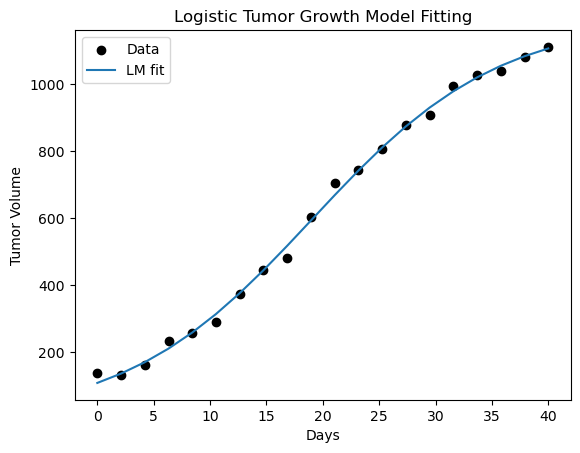

In [50]:
params_lm, _ = curve_fit(
    logistic,
    days,
    V,
    #p0 = [0,0,0],
    p0=[500, 1, 1],
    method='lm'  # no bounds allowed
)

V_lm = logistic(days, *params_lm)

K_lm, r_lm, A_lm = params_lm
print(f"True values:    K={K:.2f}. r={r:.2f}. A={A:.2f}")
print(f"LM fit:         K={K_lm:.2f}. r={r_lm:.2f}. A={A_lm:.2f}")

plt.scatter(days, V, label="Data", color="black")
plt.plot(days, V_lm, label="LM fit")
plt.xlabel("Days")
plt.ylabel("Tumor Volume")
plt.legend()
plt.title("Logistic Tumor Growth Model Fitting")
plt.show()

With the initial quess values the fit is very close to the true values.

In this case LM does not violate physiological bounds such as: negative values of K, r or A.

#### TRF

True values:    K=1200.00. r=0.12. A=10.00
trf fit:         K=1194.82. r=0.12. A=9.97


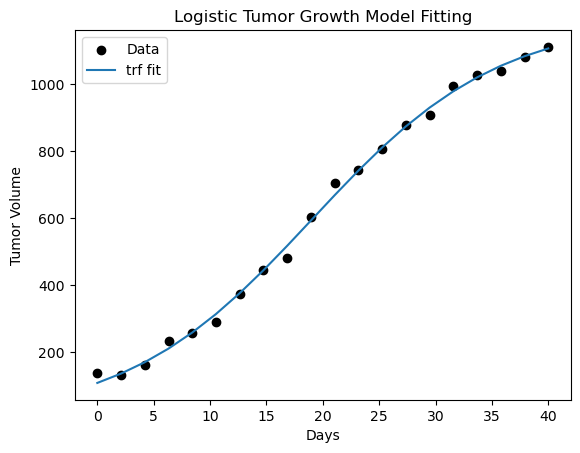

In [51]:
params_trf, _ = curve_fit(
    logistic,
    days,
    V,
    #p0 = [0,0,0],
    p0=[500, 1, 1],
    method='trf',
    bounds=([0, 0, 0], [5000, 1, 100])  # bounds
)

V_trf = logistic(days, *params_trf)

K_trf, r_trf, A_trf = params_trf

print(f"True values:    K={K:.2f}. r={r:.2f}. A={A:.2f}")
print(f"trf fit:         K={K_trf:.2f}. r={r_trf:.2f}. A={A_trf:.2f}")

plt.scatter(days, V, label="Data", color="black")
plt.plot(days, V_trf, label="trf fit")
plt.xlabel("Days")
plt.ylabel("Tumor Volume")
plt.legend()
plt.title("Logistic Tumor Growth Model Fitting")
plt.show()

The fit is identical to the fit from LM.

As long as the initla quess is ok and the boundaries are realistic, the algorithm is stable.